In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import lmdiag
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import linear_harvey_collier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.regressionplots import plot_fit
from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor


dados = pd.read_csv("base_eletronicos.csv", encoding="latin-1")
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   renda_media      200 non-null    float64
 1   inv_publicidade  200 non-null    float64
 2   vendas           200 non-null    float64
dtypes: float64(3)
memory usage: 4.8 KB


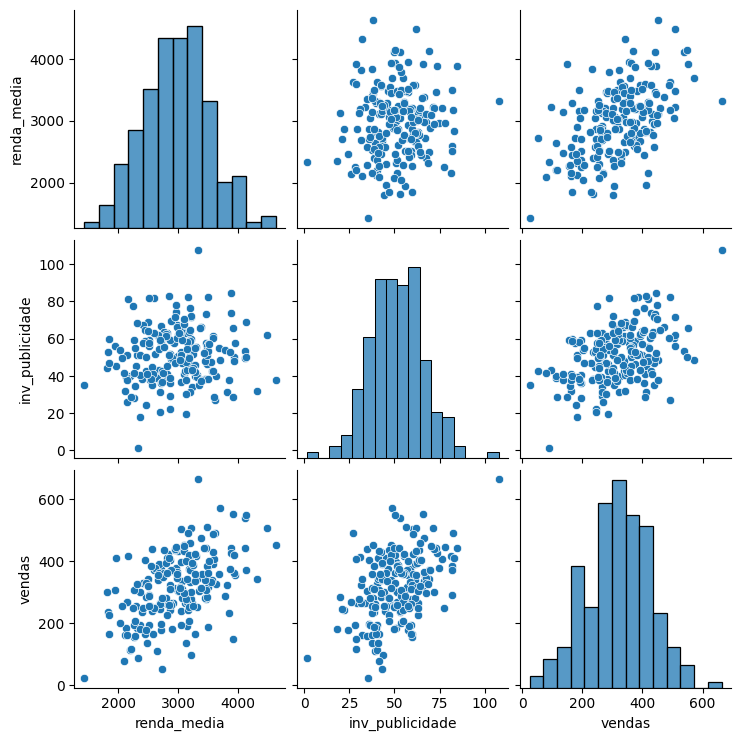

In [33]:
# Exibe a Matriz de Dispersão
sns.pairplot(dados)

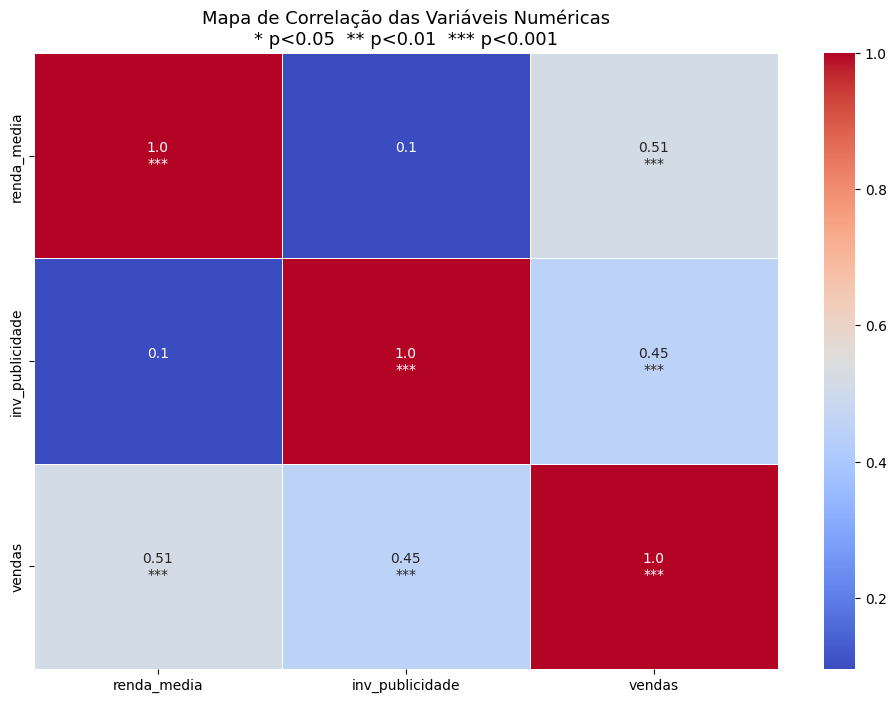

In [34]:
# Calcula correlação e p-valores
corr = dados.corr(numeric_only=True, method="pearson")
df_num = dados.select_dtypes(include="number")
pval = pd.DataFrame(
    spearmanr(df_num, nan_policy="omit").pvalue,
    columns=corr.columns, index=corr.index
)

# Cria anotações com asteriscos
def significancia(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

annot = corr.round(2).astype(str) + "\n" + pval.map(significancia)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=annot, cmap='coolwarm', fmt='', linewidths=0.5)
plt.title("Mapa de Correlação das Variáveis Numéricas\n* p<0.05  ** p<0.01  *** p<0.001", fontsize=13)
plt.show()

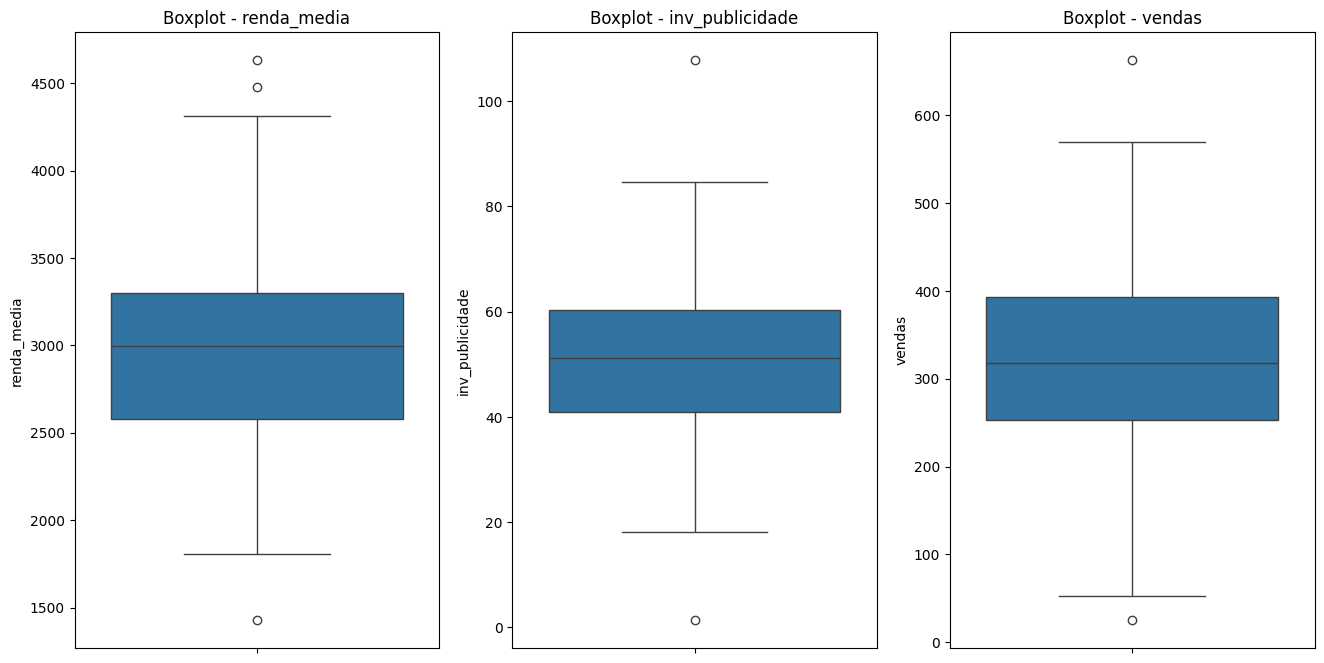

In [35]:
cols = ['renda_media', 'inv_publicidade', 'vendas'] 
fig, axes = plt.subplots(1,3, figsize=(16, 8))
for i, col in enumerate(cols):
    sns.boxplot(y=dados[col], data=dados, ax=axes[i])
    axes[i].set_title(f'Boxplot - {col}')
plt.show()

In [36]:
#verificando se as variavies tem multicolinearidade
X = dados.drop('vendas', axis=1).reset_index(drop=True);
# Adiciona a constante
X = sm.add_constant(X)
y = dados['vendas']
# Calculando o VIF para cada variável
vif_data = pd.DataFrame()
vif_data["Variável"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

          Variável        VIF
0            const  38.387472
1      renda_media   1.009134
2  inv_publicidade   1.009134


In [47]:
# TREINO E TESTE usando a base completa para manter a fórmula simples
from sklearn.model_selection import train_test_split
# Divisão dos dados em Treino e Teste diretamente em DataFrames
train_df, test_df = train_test_split(dados, test_size=0.3, random_state=1)


In [48]:
# Ajustando o modelo de regressão linear com fórmula usando treino e teste
formula = 'vendas ~ renda_media + inv_publicidade'
modelo_fml = smf.ols(formula, data=train_df).fit()
print(modelo_fml.summary())

# Previsões em treino e teste
y_train_pred = modelo_fml.predict(train_df)
y_test_pred = modelo_fml.predict(test_df)

                            OLS Regression Results                            
Dep. Variable:                 vendas   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     42.04
Date:                Mon, 18 May 2026   Prob (F-statistic):           7.85e-15
Time:                        15:04:02   Log-Likelihood:                -768.12
No. Observations:                 134   AIC:                             1542.
Df Residuals:                     131   BIC:                             1551.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -81.5560     44.146     

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

resultados = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "R²"],
    "Treino":  [mean_absolute_error(train_df["vendas"], y_train_pred),
                mean_squared_error(train_df["vendas"],  y_train_pred),
                r2_score(train_df["vendas"],            y_train_pred)],
    "Teste":   [mean_absolute_error(test_df["vendas"],  y_test_pred),
                mean_squared_error(test_df["vendas"],   y_test_pred),
                r2_score(test_df["vendas"],             y_test_pred)]
}).round(4)

print(resultados.to_string(index=False))

Métrica    Treino     Teste
    MAE   61.5523   56.7716
    MSE 5578.3557 5474.7185
     R²    0.3909    0.4996


### REALIZANDO A ANÁLISE DE RESÍDUOS
#### 1-ajustando o modelo com dados completos

In [40]:
# ajustando modelo de regressão linear com dados de treino/teste e exibindo o resumo do modelo
modelo = smf.ols(formula, data=dados).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 vendas   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     72.99
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.91e-24
Time:                        14:26:11   Log-Likelihood:                -1162.0
No. Observations:                 200   AIC:                             2330.
Df Residuals:                     197   BIC:                             2340.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        -101.6719     35.630     

In [50]:

#teste de normalidade dos resíduos
stat, p = stats.shapiro(modelo.resid)
print(f'teste de Shapiro-Wilk: {stat:.4f}, p-valor: {p:.4f}')

#teste de heterocedasticidade dos resíduos
lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(
    modelo.resid, 
    modelo.model.exog
)
print(f'teste de heterocedasticidade: LM Stat: {lm_stat:.4f}, LM p-valor: {lm_pvalue:.4f}', f'F Stat: {f_stat:.4f}, F p-valor: {f_pvalue:.4f}')

#teste de linearidade dos resíduos
linear_harvey_collier(modelo)
t_stat, p_value = linear_harvey_collier(modelo)
print(f'Estatística de linearidade: t_stat:{t_stat:.4f}', f'p-valor: {p_value:.4f}')


teste de Shapiro-Wilk: 0.9913, p-valor: 0.2995
teste de heterocedasticidade: LM Stat: 0.7948, LM p-valor: 0.6721 F Stat: 0.3928, F p-valor: 0.6757
Estatística de linearidade: t_stat:-0.8613 p-valor: 0.3902


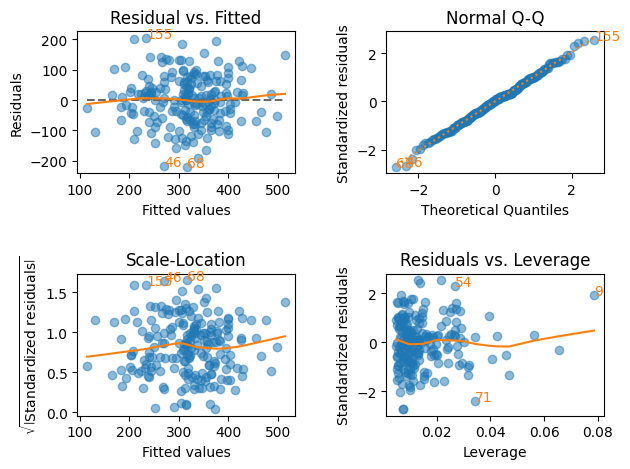

In [42]:
fig = lmdiag.plot(modelo)

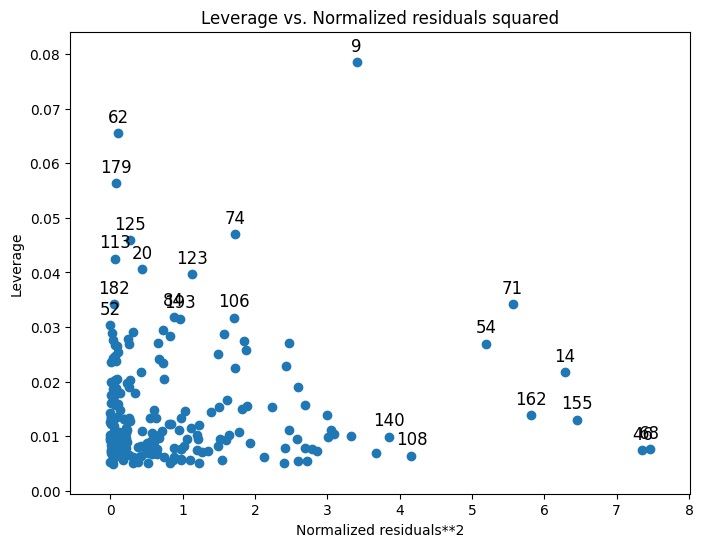

In [43]:
from statsmodels.graphics.regressionplots import plot_leverage_resid2

fig, ax = plt.subplots(figsize=(8, 6))
fig = plot_leverage_resid2(modelo, ax=ax)

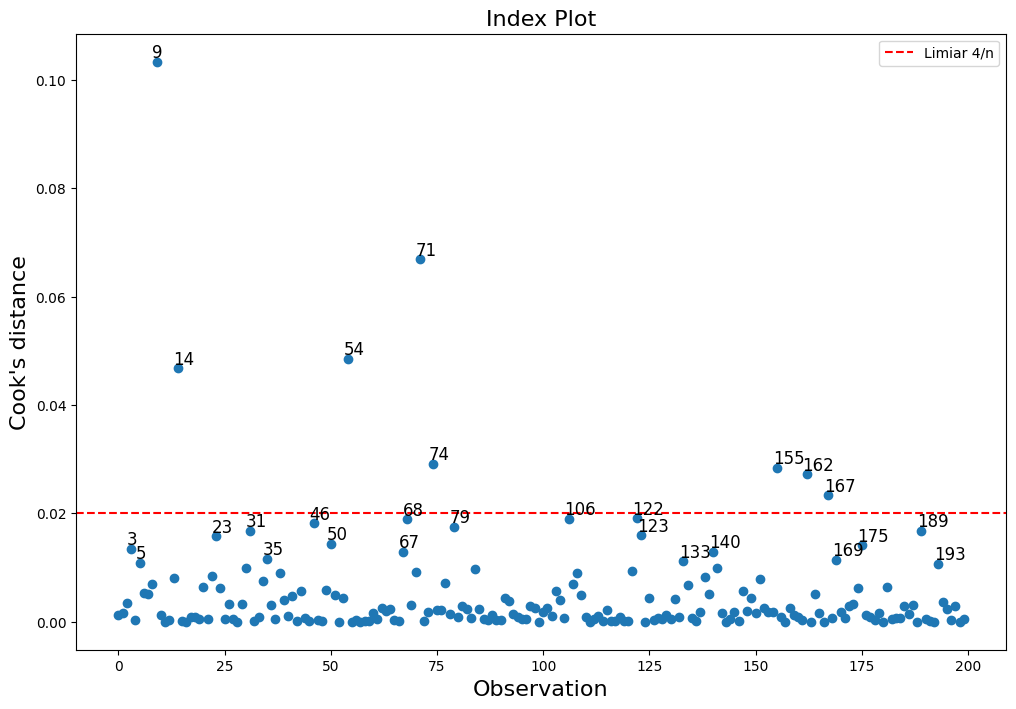

In [44]:
infl = modelo.get_influence()
fig = infl.plot_index(y_var="cooks", threshold=2 * infl.cooks_distance[0].mean())
ax = fig.axes[0]
ax.axhline(4 / len(modelo.fittedvalues), color="red", linestyle="--", label="Limiar 4/n")
ax.legend()
fig.set_size_inches(12, 8)


In [ ]:
# ajustando modelo de regressão linear sem a unidade problemáticas identificada no gráfico de influência
dados= dados.drop(index= [9, 14, 54, 71, 74, 155, 162, 167])
modelo = smf.ols(formula, data=dados).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 vendas   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     71.77
Date:                Mon, 18 May 2026   Prob (F-statistic):           6.49e-24
Time:                        14:26:14   Log-Likelihood:                -1099.5
No. Observations:                 192   AIC:                             2205.
Df Residuals:                     189   BIC:                             2215.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -92.3401     34.731     

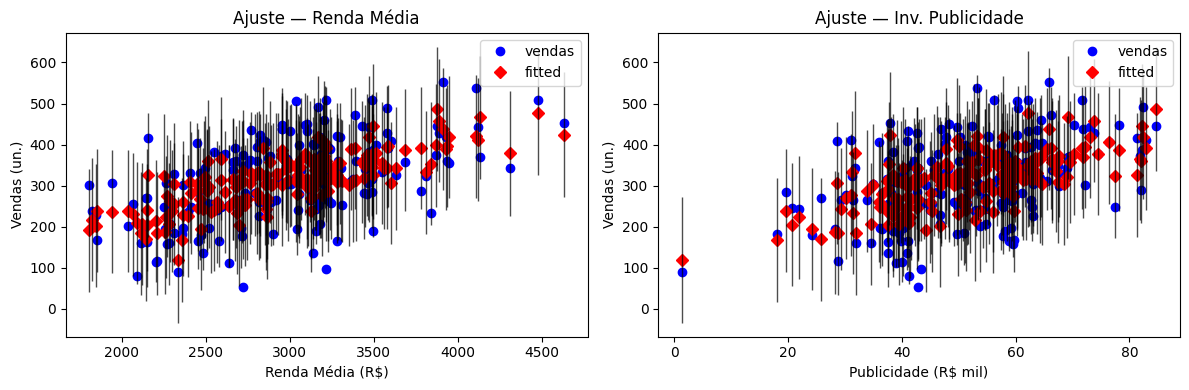

In [46]:
# esse gráfico reesponde a pergunta como
# 1-Como as vendas variam com a Renda, mantendo a Publicidade constante na média
# 2-Como as vendas variam com a Publicidade, mantendo a Renda constante na média
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1 — Renda
plot_fit(modelo, exog_idx="renda_media", ax=axes[0])
axes[0].set_title("Ajuste — Renda Média")
axes[0].set_xlabel("Renda Média (R$)")
axes[0].set_ylabel("Vendas (un.)")

# Gráfico 2 — Publicidade
plot_fit(modelo, exog_idx="inv_publicidade", ax=axes[1])
axes[1].set_title("Ajuste — Inv. Publicidade")
axes[1].set_xlabel("Publicidade (R$ mil)")
axes[1].set_ylabel("Vendas (un.)")

plt.tight_layout()
plt.show()